In [21]:
import tidy3d as td

# size of simulation domain
# Lx, Ly, Lz = 1, 2, 3
Lx, Ly, Lz = 1.5, 1.5, 1.5
dl = 0.066667

# waveguide information
wg_permittivity = 3.477 ** 2

# automatic grid specification
# grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)
grid_spec = td.GridSpec.uniform(dl=dl)
# mesh = td.TriangleMesh.from_stl("./models/unit_cube.stl")
# mesh = td.TriangleMesh.from_stl("./models/busted.stl")
mesh = td.TriangleMesh.from_stl("./wg.stl", scale=1)

tmesh = mesh.trimesh
# tmesh.rezero()
# tmesh.apply_translation(-tmesh.centroid)

bmesh = tmesh.bounding_box
bmesh.visual.face_colors = [115, 112, 255, 100]
print("center:", mesh.bounding_box.center)
print("size:", mesh.bounding_box.size)

# (tmesh).show(viewer='gl')

geometry = mesh

geometry2 = td.Box(center=(0., 0, 0), size=(0.5,1,1))


center: (0.0, 0.0, -1.4901199999611814e-07)
size: (0.499999940396, 0.40000000596, 0.22000046074399998)


<Axes: title={'center': 'cross section at y=0.00'}, xlabel='x', ylabel='z'>

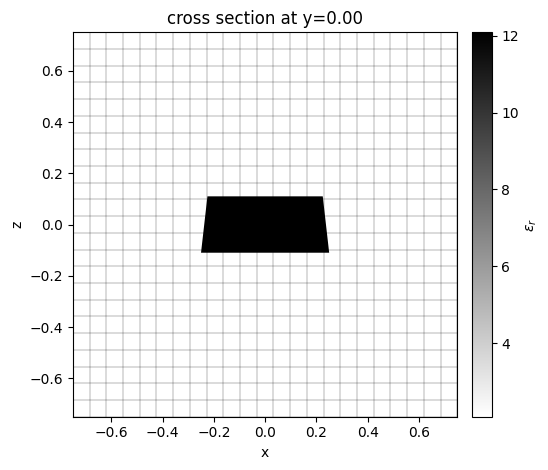

In [22]:
waveguide = td.Structure(
    geometry=geometry,
    medium=td.Medium(permittivity=wg_permittivity),
)

# waveguide2 = td.Structure(
#     geometry=geometry2,
#     medium=td.Medium(permittivity=wg_permittivity),
# )

sim = td.Simulation(
    center=[0, 0, 0],
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
    medium=td.Medium(permittivity=1.444**2),
)

ax = sim.plot_grid(y=0)
sim.plot_structures_eps(y=0, ax=ax, alpha=1)
# sim.plot_3d()

use sim to generate spatial medium

In [23]:
import custom.spatial_medium as sm
sm.SpatialMediumCreator5.MAX_ITERATIONS = 5
creator = sm.SpatialMediumCreator5(sim)

medium_new, cell_permittivity = creator.create()
# waveguide.medium = medium

process total cells: 97336 on 20 cores, iterations: 5
Calc Time elapsed: 412.3733183000004
Average Time elapsed: 42.63928339999984


In [24]:
# debug data
def is_sysmmetric_x(celly):
    for x in celly:
        return all(x == x[::-1])
    
celly0 = cell_permittivity[:, cell_permittivity.shape[1]//2, :].T
print(is_sysmmetric_x(celly0))

shape = cell_permittivity.shape

for i in range(shape[1]):
    assert is_sysmmetric_x(cell_permittivity[:, i, :].T)

permittivity = medium_new.permittivity
pery0 = permittivity[:, permittivity.shape[1]//2, :].T
print(is_sysmmetric_x(pery0.values))

True
True


In [26]:

from __future__ import annotations

from typing import List, Tuple, Union

import autograd.numpy as np

from tidy3d import Box, Grid, Medium, Structure, inf, Coords
from matplotlib.axes import Axes as Ax
from shapely.geometry.base import BaseGeometry as Shapely
from shapely.plotting import plot_polygon
from tidy3d.components.viz import polygon_path


def bounds(structures: List[Structure]) -> Tuple[Tuple[float, float, float], Tuple[float, float, float]]:
    bounds = tuple(structure.geometry.bounds for structure in structures)
    return (
        tuple(min((b[i] for b, _ in bounds if b[i] != -inf), default=-1) for i in range(3)),
        tuple(max((b[i] for _, b in bounds if b[i] != inf), default=1) for i in range(3)),
    )

def _get_structures_2dbox(
        bounds,
        structures: List[Structure],
        x: float = None,
        y: float = None,
        z: float = None,
        hlim: Tuple[float, float] = None,
        vlim: Tuple[float, float] = None,
    ) -> List[Tuple[Medium, Shapely]]:
        # if no hlim and/or vlim given, the bounds will then be the usual pml bounds
        axis, _ = Box.parse_xyz_kwargs(x=x, y=y, z=z)
        _, (hmin, vmin) = Box.pop_axis(bounds[0], axis=axis)
        _, (hmax, vmax) = Box.pop_axis(bounds[1], axis=axis)

        if hlim is not None:
            (hmin, hmax) = hlim
        if vlim is not None:
            (vmin, vmax) = vlim

        # get center and size with h, v
        h_center = (hmin + hmax) / 2.0
        v_center = (vmin + vmax) / 2.0
        h_size = (hmax - hmin) or inf
        v_size = (vmax - vmin) or inf

        axis, center_normal = Box.parse_xyz_kwargs(x=x, y=y, z=z)
        center = Box.unpop_axis(center_normal, (h_center, v_center), axis=axis)
        size = Box.unpop_axis(0.0, (h_size, v_size), axis=axis)
        plane = Box(center=center, size=size)

        medium_shapes = []
        for structure in structures:
            intersections = plane.intersections_with(structure.geometry)
            for shape in intersections:
                if not shape.is_empty:
                    shape = Box.evaluate_inf_shape(shape)
                    medium_shapes.append((structure.medium, shape))
        return medium_shapes

def _pcolormesh_shape_custom_medium_structure_eps(
        x: float,
        y: float,
        z: float,
        freq: float,
        alpha: float,
        medium: td.Medium,
        eps_min: float,
        eps_max: float,
        clip: bool,
        shape: Shapely,
        ax: Ax,
        grid: Grid,
    ):
        """
        Plot shape made of custom medium with ``pcolormesh``.
        """
        coords = "xyz"
        normal_axis_ind, normal_position = Box.parse_xyz_kwargs(x=x, y=y, z=z)
        normal_axis, plane_axes = Box.pop_axis(coords, normal_axis_ind)
        
        # make grid for eps interpolation
        # we will do this by combining shape bounds and points where custom eps is provided
        shape_bounds = shape.bounds
        rmin, rmax = [*shape_bounds[:2]], [*shape_bounds[2:]]
        rmin.insert(normal_axis_ind, normal_position)
        rmax.insert(normal_axis_ind, normal_position)
        span_inds = grid.discretize_inds(Box.from_bounds(rmin=rmin, rmax=rmax), extend=True)
        # filter negative or too large inds
        n_grid = [len(grid_comp) for grid_comp in grid.boundaries.to_list]
        span_inds = [
            (max(fmin, 0), min(fmax, n_grid[f_ind]))
            for f_ind, (fmin, fmax) in enumerate(span_inds)
        ]

        # assemble the coordinate in the 2d plane
        plane_coord = []
        for plane_axis in range(2):
            ind_axis = "xyz".index(plane_axes[plane_axis])
            plane_coord.append(grid.boundaries.to_list[ind_axis][slice(*span_inds[ind_axis])])

        # prepare `Coords` for interpolation
        coord_dict = {
            plane_axes[0]: plane_coord[0],
            plane_axes[1]: plane_coord[1],
            normal_axis: [normal_position],
        }
        coord_shape = Coords(**coord_dict)
        # interpolate permittivity and take the average over components
        tmp = medium.eps_diagonal_on_grid(frequency=freq, coords=coord_shape)
        eps_shape = np.mean(medium.eps_diagonal_on_grid(frequency=freq, coords=coord_shape), axis=0)
        # remove the normal_axis and take real part
        eps_shape = eps_shape.real.mean(axis=normal_axis_ind)
        # reverse
        # if reverse:
        #     eps_shape = eps_min + eps_max - eps_shape

        # pcolormesh
        plane_xp, plane_yp = np.meshgrid(plane_coord[0], plane_coord[1], indexing="ij")
        ax.pcolormesh(
            plane_xp,
            plane_yp,
            eps_shape,
            clip_path=clip and (polygon_path(shape), ax.transData) or None,
            cmap='viridis',
            vmin=eps_min,
            vmax=eps_max,
            alpha=alpha,
            clip_box=ax.bbox,
        )

def plot_structures_eps(
    structures: List[Structure],
    x: float = None,
    y: float = None,
    z: float = None,
    freq: float = None,
    eps_lim: Tuple[Union[float, None], Union[float, None]] = (None, None),
    ax: Ax = None,
    hlim: Tuple[float, float] = None,
    vlim: Tuple[float, float] = None,
    grid: Grid = None,
    clip: bool = True,
) -> Ax:
    structures = list(structures)
    medium_shapes = _get_structures_2dbox(
        bounds=bounds(structures),
        structures=structures, x=x, y=y, z=z, hlim=hlim, vlim=vlim
    )
    eps_min, eps_max = eps_lim
    for medium, shape in medium_shapes:
        # For custom medium, apply pcolormesh clipped by the shape.
        _pcolormesh_shape_custom_medium_structure_eps(
            x, y, z, freq, 1, medium, eps_min, eps_max, clip, shape, ax, grid
        )
        plot_polygon(shape, ax=ax, edgecolor="black", facecolor="none", add_points=False)

    return ax

def background_structure(sim) -> Structure:
    geometry = Box(size=(inf, inf, inf))
    return Structure(geometry=geometry, medium=sim.medium)

visualize the medium

12.089528999999999
1.0


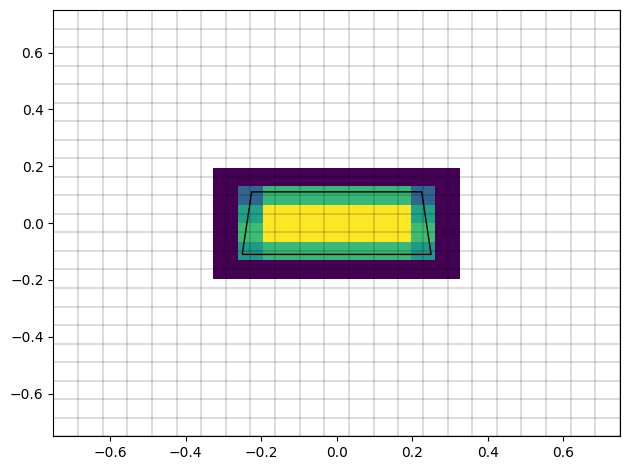

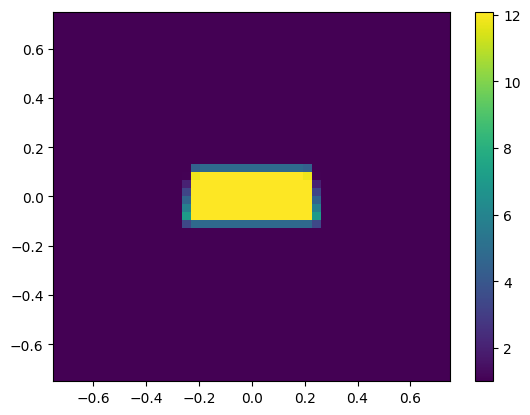

In [27]:
import numpy as np
import matplotlib.pyplot as plt

plane = td.Box(center=(0, 0, 0), size=(4, 0, 3.5))
mode_spec = td.ModeSpec(
    num_modes=3,
    target_neff=2.0,
)
from tidy3d.constants import C_0

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3
num_freqs = 11
f0_ind = num_freqs // 2
freqs = np.linspace(freq0 - fwidth / 2, freq0 + fwidth / 2, num_freqs)

waveguide = td.Structure(
    geometry=geometry,
    medium=medium_new,
)

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide],
    run_time=1e-12,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
    medium=td.Medium(permittivity=1.444**2),
)

ax = sim.plot_grid(y=0)
# sim.plot_structures_eps(y=0, ax=ax)
celly0 = cell_permittivity[:, cell_permittivity.shape[1]//2, :].T
plot_structures_eps([waveguide], y=0, freq=freq0, eps_lim=(np.min(celly0), np.max(celly0)), ax=ax, grid=sim.grid, clip=False)
# print(np.where(cell_permittivity>1., cell_permittivity, -1))

print(np.max(cell_permittivity))
print(np.min(cell_permittivity))
plt.figure()
plt.imshow(celly0, origin='lower', aspect='auto', extent=[-Lx/2, Lx/2, -Lz/2, Lz/2])
plt.colorbar()


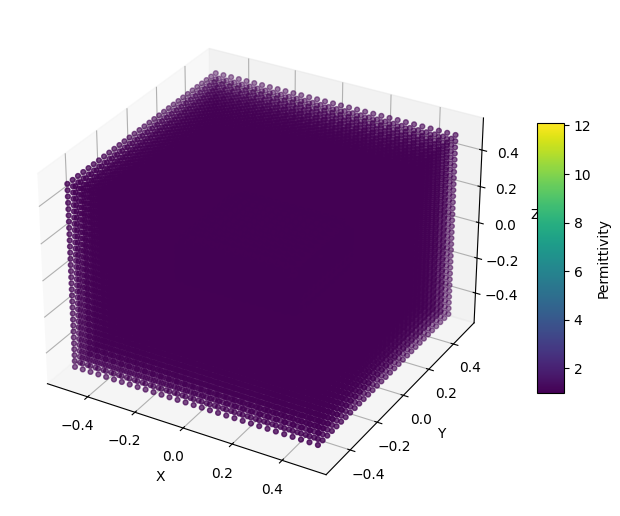

In [26]:
permittivity: td.SpatialDataArray = medium_new.permittivity  # type: ignore

if True:
    X,Y,Z = np.meshgrid(permittivity.x, permittivity.y, permittivity.z, indexing='ij')
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    X_1 = X.flatten()
    Y_1 = Y.flatten()
    Z_1 = Z.flatten()
    E_1 = permittivity.values.flatten()
    scatter = ax.scatter(X_1, Y_1, Z_1, s=E_1*12, c=E_1, cmap='viridis', marker='o')
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
    cbar.set_label('Permittivity')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

import vedo
vedo.settings.default_backend = 'vtk'
sim_box = vedo.Box(
 pos=sim.bounding_box.center,
 size=sim.size,
 c='g2',
 alpha=0.1
)
plotter = vedo.Plotter()

if True:
    x_bounds = [float(permittivity.x.min()), float(permittivity.x.max())]
    y_bounds = [float(permittivity.y.min()), float(permittivity.y.max())]
    z_bounds = [float(permittivity.z.min()), float(permittivity.z.max())]

    X_2, Y_2 = np.meshgrid(permittivity.x, permittivity.y)
    start_pts = np.array([X_2.flatten(), Y_2.flatten(), np.ones_like(X_2.flatten()) * z_bounds[0]]).T
    end_pts = np.array([X_2.flatten(), Y_2.flatten(), np.ones_like(X_2.flatten()) * z_bounds[1]]).T

    Y_2, Z_2 = np.meshgrid(permittivity.y, permittivity.z)
    start_pts = np.vstack([start_pts, np.array([np.ones_like(Y_2.flatten()) * x_bounds[0], Y_2.flatten(), Z_2.flatten()]).T])
    end_pts = np.vstack([end_pts, np.array([np.ones_like(Y_2.flatten()) * x_bounds[1], Y_2.flatten(), Z_2.flatten()]).T])

    X_2, Z_2 = np.meshgrid(permittivity.x, permittivity.z)
    start_pts = np.vstack([start_pts, np.array([X_2.flatten(), np.ones_like(Z_2.flatten()) * y_bounds[0], Z_2.flatten()]).T])
    end_pts = np.vstack([end_pts, np.array([X_2.flatten(), np.ones_like(Z_2.flatten()) * y_bounds[1], Z_2.flatten()]).T])

    lines = vedo.Lines(start_pts, end_pts, c='k')

    plotter.add(lines)

original_shape = cell_permittivity.shape
new_shape = (original_shape[0] + 2, original_shape[1] + 2, original_shape[2] + 2)
new_data_matrix = np.zeros(new_shape, dtype=np.uint8)
new_data_matrix[1:-1, 1:-1, 1:-1] = cell_permittivity

vol1 = vedo.Volume(new_data_matrix, spacing=(dl, dl, dl), origin=(-(Lx+dl)/2, -(Ly+dl)/2, -(Lz+dl)/2))
vol1.cmap(['white','b','r']).mode(1).off()
plotter.add(vol1)


vol2 = vedo.Volume(permittivity.values, spacing=(dl, dl, dl), origin=(-(Lx)/2, -(Ly)/2, -(Lz)/2))
vol2.cmap(['white','b', 'r']).mode(1)
plotter.add(vol2)

plotter.add(sim_box)
structures = vedo.Mesh([tmesh.vertices, tmesh.faces])
structures.c('y').alpha(0.4)
plotter.add(structures)

def buttonfunc(obj, ename):
    structures.toggle()
    obj.switch()

plotter.add_button(
    buttonfunc,
    pos=(0.9, 0.1),   # x,y fraction from bottom left corner
    states=["hide s", "show s"],  # text for each state
    c=["w", "r"],     # font color for each state
    bc=["dg", "dv"],  # background color for each state
    size=30,          # font size
    bold=True,        # bold font
    italic=False,     # non-italic font style
)
def buttonfunc2(obj, ename):
    vol1.toggle()
    vol2.toggle()
    obj.switch()


def buttonfunc3(obj, ename):
    lines.toggle()

plotter.add_button(
    buttonfunc2,
    pos=(0.9, 0.2),   # x,y fraction from bottom left corner
    states=["coords", "cell"],  # text for each state
    c=["w", "r"],     # font color for each state
    size=30,          # font size
    bold=True,        # bold font
    italic=False,     # non-italic font style
)

plotter.add_button(
    buttonfunc3,
    pos=(0.9, 0.3),   # x,y fraction from bottom left corner
    states=["lines"],  # text for each state
    c=["g", "r"],     # font color for each state
    size=30,          # font size
    bold=True,        # bold font
    italic=False,     # non-italic font style
)

plotter.show(viewup='z', axes=1).close()

In [5]:
from tidy3d.plugins.mode.mode_solver import ModeSolver

mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()


16:52:53 中国标准时间 WARNING: Use the remote mode solver with subpixel         
                      averaging for better accuracy through                     
                      'tidy3d.plugins.mode.web.run(...)'.                       

                WARNING: Client-side permittivity of a 'TriangleMesh' may be    
                inaccurate if the mesh is not unionized. We recommend unionizing
                all meshes before import. A 'PermittivityMonitor' can be used to
                obtain the true permittivity and check that the surface mesh is 
                loaded correctly.                                               

                WARNING: Client-side permittivity of a 'TriangleMesh' may be    
                inaccurate if the mesh is not unionized. We recommend unionizing
                all meshes before import. A 'PermittivityMonitor' can be used to
                obtain the true permittivity and check that the surface mesh is 
                loaded correctly.                                               

                WARNING: Client-side permittivity of a 'TriangleMesh' may be    
                inaccurate if the mesh is not unionized. We recommend unionizing
                all meshes before import. A 'PermittivityMonitor' can be used to
                obtain the true permittivity and check that the surface mesh is 
                loaded correctly.                                               

                WARNING: Client-side permittivity of a 'TriangleMesh' may be    
                inaccurate if the mesh is not unionized. We recommend unionizing
                all meshes before import. A 'PermittivityMonitor' can be used to
                obtain the true permittivity and check that the surface mesh is 
                loaded correctly.                                               

...

                WARNING: Mode field at frequency index 4, mode index 2 does not 
                decay at the plane boundaries.                                  

16:52:57 中国标准时间 WARNING: Mode field at frequency index 5, mode index 2    
                      does not decay at the plane boundaries.                   

                WARNING: Mode field at frequency index 6, mode index 2 does not 
                decay at the plane boundaries.                                  

                WARNING: Mode field at frequency index 7, mode index 0 does not 
                decay at the plane boundaries.                                  

                WARNING: Mode field at frequency index 8, mode index 0 does not 
                decay at the plane boundaries.                                  

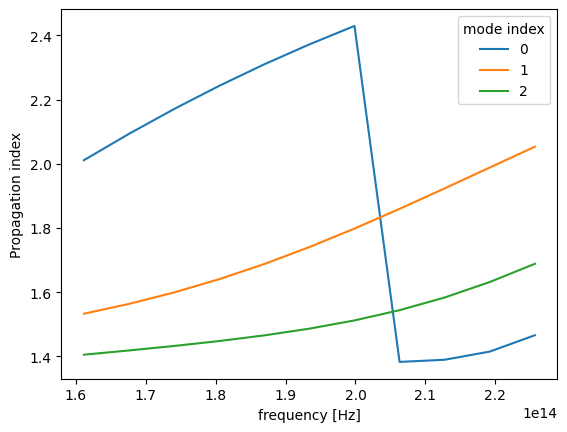

In [6]:
fig, ax = plt.subplots(1)
n_eff = mode_data.n_eff  # real part of the effective mode index
n_eff.plot.line(x="f")
plt.show()


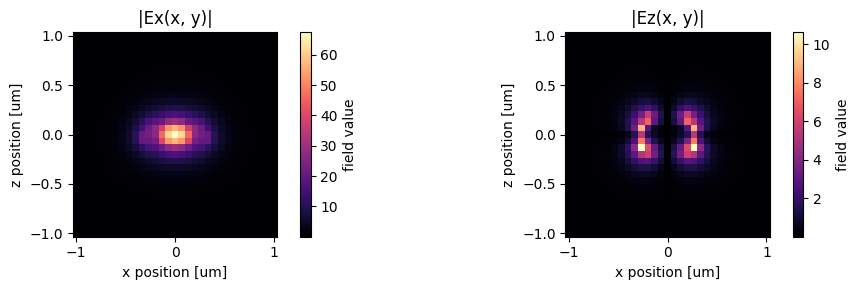

In [9]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()


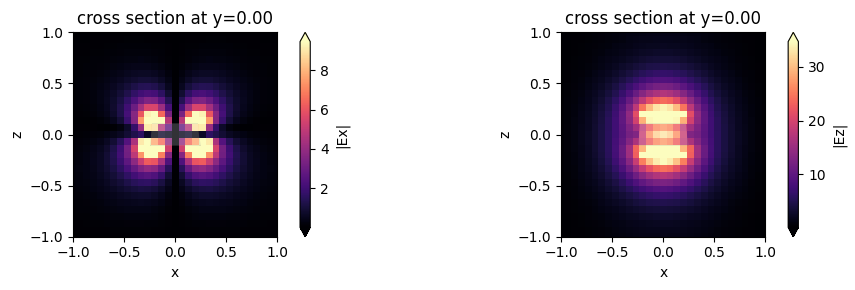

In [9]:
mode_index = 1
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
mode_solver.plot_field("Ex", "abs", mode_index=mode_index, f=freq0, ax=ax1)
mode_solver.plot_field("Ez", "abs", mode_index=mode_index, f=freq0, ax=ax2)
plt.show()


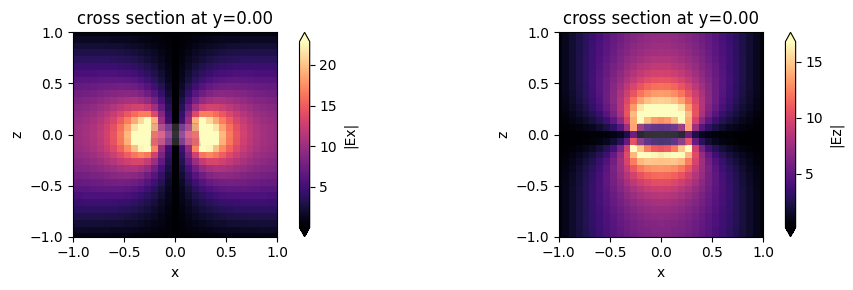

In [10]:
mode_index = 2
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
mode_solver.plot_field("Ex", "abs", mode_index=mode_index, f=freq0, ax=ax1)
mode_solver.plot_field("Ez", "abs", mode_index=mode_index, f=freq0, ax=ax2)
plt.show()
